train.py
builds a random forest model to predict NBA MVP using historical data.
trains on seasons 2000-2024, then predicts the 2026 winner.

usage:
pip install scikit-learn pandas numpy
python train.py

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

data  = "data"
TEST_YEAR = 2025   # hold out this season to test accuracy before predicting 2026

# load data

pg  = pd.read_csv(f"{data}/per_game_stats.csv")
adv = pd.read_csv(f"{data}/advanced_stats.csv")
aw  = pd.read_csv(f"{data}/award_winners.csv")
rec = pd.read_csv(f"{data}/team_records.csv")

print(f"loaded {len(pg):,} per-game columns")
print(f"loaded {len(adv):,} advanced columns")
print(f"loaded {len(aw):,} award columns")
print(f"loaded {len(rec):,} team record columns")

loaded 16,649 per-game columns
loaded 16,649 advanced columns
loaded 26 award columns
loaded 805 team record columns


In [112]:
pg_cols  = ["Player", "season", "Pos", "G", "GS", "MP", "PTS", "AST", "TRB", "STL", "BLK", "TOV", "FG%", "FT%", "3P%", "Team"]
adv_cols = ["Player", "season", "PER", "WS", "WS/48", "BPM", "VORP", "OBPM", "DBPM", "USG%", "TS%"]

pg_raw = pg.copy()

pg  = pg[pg_cols].copy()
adv = adv[adv_cols].copy()
# fix encoding issues (e.g. Jokić showing up differently)
df["Player"] = df["Player"].str.normalize("NFKD")

for col in ["G", "GS", "MP", "PTS", "AST", "TRB", "STL", "BLK", "TOV", "FG%", "FT%", "3P%"]:
    pg[col] = pd.to_numeric(pg[col], errors="coerce")

for col in ["PER", "WS", "WS/48", "BPM", "VORP", "OBPM", "DBPM", "USG%", "TS%"]:
    adv[col] = pd.to_numeric(adv[col], errors="coerce")

for col in ["W", "L", "W/L%"]:
    
    rec[col] = pd.to_numeric(rec[col], errors="coerce")
print(f"pg:  {len(pg):,} rows, {len(pg.columns)} columns")
print(f"adv: {len(adv):,} rows, {len(adv.columns)} columns")
print(f"rec: {len(rec):,} rows, {len(rec.columns)} columns")
pg.head()

pg:  16,649 rows, 16 columns
adv: 16,649 rows, 11 columns
rec: 805 rows, 6 columns


,Player,season,Pos,G,GS,MP,PTS,AST,TRB,STL,BLK,TOV,FG%,FT%,3P%,Team
0,Shaquille O'Neal,2000,C,79.0,79.0,40.0,29.7,3.8,13.6,0.5,3.0,2.8,0.574,0.524,0.000,LAL
1,Allen Iverson,2000,SG,70.0,70.0,40.8,28.4,4.7,3.8,2.1,0.1,3.3,0.421,0.713,0.341,PHI
2,Grant Hill,2000,SF,74.0,74.0,37.5,25.8,5.2,6.6,1.4,0.6,3.2,0.489,0.795,0.347,DET
3,Vince Carter,2000,SF,82.0,82.0,38.1,25.7,3.9,5.8,1.3,1.1,2.2,0.465,0.791,0.403,TOR
4,Karl Malone,2000,PF,82.0,82.0,35.9,25.5,3.7,9.5,1.0,0.9,2.8,0.509,0.797,0.250,UTA


In [90]:
df = pg.merge(adv, on=["Player", "season"], how="inner")
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

27,131 rows, 25 columns


,Player,season,Pos,G,GS,MP,PTS,AST,TRB,STL,...,Team,PER,WS,WS/48,BPM,VORP,OBPM,DBPM,USG%,TS%
0,Shaquille O'Neal,2000,C,79.0,79.0,40.0,29.7,3.8,13.6,0.5,...,LAL,30.6,18.6,0.283,9.3,9.0,7.3,2.0,31.2,0.578
1,Allen Iverson,2000,SG,70.0,70.0,40.8,28.4,4.7,3.8,2.1,...,PHI,20.0,6.9,0.116,3.2,3.8,3.4,-0.2,34.4,0.496
2,Grant Hill,2000,SF,74.0,74.0,37.5,25.8,5.2,6.6,1.4,...,DET,24.5,10.7,0.185,5.4,5.2,5.4,0.1,30.5,0.565
3,Vince Carter,2000,SF,82.0,82.0,38.1,25.7,3.9,5.8,1.3,...,TOR,23.4,11.8,0.182,5.5,5.9,5.6,-0.1,30.0,0.543
4,Karl Malone,2000,PF,82.0,82.0,35.9,25.5,3.7,9.5,1.0,...,UTA,27.1,15.3,0.249,7.5,7.1,6.4,1.1,31.9,0.582


In [91]:
rec["Team"] = rec["Team"].str.strip()
df["Team"]  = df["Team"].str.strip()

# Clean up any duplicate columns from previous merges
cols_to_drop = [col for col in df.columns if col in ['W', 'W/L%', 'Abbreviation'] or (col.endswith(('_x', '_y')) and any(x in col for x in ['W', 'W/L%', 'Abbreviation']))]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("df columns before merge:", df.columns.tolist())
df = df.merge(rec[["Abbreviation", "season", "W", "W/L%"]], left_on=["Team", "season"], right_on=["Abbreviation", "season"], how="left")
df.drop(columns=["Abbreviation"], inplace=True)
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df[["Player", "season", "Team", "W", "W/L%"]].head(10)

df columns before merge: ['Player', 'season', 'Pos', 'G', 'GS', 'MP', 'PTS', 'AST', 'TRB', 'STL', 'BLK', 'TOV', 'FG%', 'FT%', '3P%', 'Team', 'PER', 'WS', 'WS/48', 'BPM', 'VORP', 'OBPM', 'DBPM', 'USG%', 'TS%']
27,131 rows, 27 columns


,Player,season,Team,W,W/L%
0,Shaquille O'Neal,2000,LAL,67.0,0.817
1,Allen Iverson,2000,PHI,49.0,0.598
2,Grant Hill,2000,DET,42.0,0.512
3,Vince Carter,2000,TOR,45.0,0.549
4,Karl Malone,2000,UTA,55.0,0.671
5,Chris Webber,2000,SAC,44.0,0.537
6,Gary Payton,2000,SEA,45.0,0.549
7,Jerry Stackhouse,2000,DET,42.0,0.512
8,Tim Duncan,2000,SAS,53.0,0.646
9,Kevin Garnett,2000,MIN,50.0,0.610


In [92]:
df[["Player", "season", "Team"]].head(10)

,Player,season,Team
0,Shaquille O'Neal,2000,LAL
1,Allen Iverson,2000,PHI
2,Grant Hill,2000,DET
3,Vince Carter,2000,TOR
4,Karl Malone,2000,UTA
5,Chris Webber,2000,SAC
6,Gary Payton,2000,SEA
7,Jerry Stackhouse,2000,DET
8,Tim Duncan,2000,SAS
9,Kevin Garnett,2000,MIN


In [93]:
rec[["Team", "season","Abbreviation"]].head(10)

,Team,season,Abbreviation
0,Miami Heat,2000,MIA
1,New York Knicks,2000,NYK
2,Philadelphia 76ers,2000,PHI
3,Orlando Magic,2000,ORL
4,Boston Celtics,2000,BOS
5,New Jersey Nets,2000,NJN
6,Washington Wizards,2000,WAS
7,Indiana Pacers,2000,IND
8,Charlotte Hornets,2000,CHH
9,Toronto Raptors,2000,TOR


In [113]:
# Recreate df from pg and adv
df = pg.merge(adv, on=["Player", "season"], how="inner")

# Merge with team records
rec["Team"] = rec["Team"].str.strip()
df["Team"]  = df["Team"].str.strip()

cols_to_drop = [col for col in df.columns if col in ['W', 'W/L%', 'Abbreviation'] or (col.endswith(('_x', '_y')) and any(x in col for x in ['W', 'W/L%', 'Abbreviation']))]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df = df.merge(rec[["Abbreviation", "season", "W", "W/L%"]], left_on=["Team", "season"], right_on=["Abbreviation", "season"], how="left")
df.drop(columns=["Abbreviation"], inplace=True)

# Merge with awards
aw["season"] = aw["season"].astype(int)
aw_mvp = aw[["season", "mvp"]].rename(columns={"mvp": "mvp_winner"})
df = df.merge(aw_mvp, on="season", how="left")
df["won_mvp"] = (df["Player"] == df["mvp_winner"]).astype(int)

print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"MVP winner rows in dataset: {df['won_mvp'].sum()}")
mvp_winners = df[df["won_mvp"] == 1][["Player", "season"]].drop_duplicates()
print(f"Unique MVP winners: {len(mvp_winners)}")
print("All unique MVP winners:")
mvp_winners

27,131 rows, 29 columns
MVP winner rows in dataset: 26
Unique MVP winners: 26
All unique MVP winners:


,Player,season
0,Shaquille O'Neal,2000
671,Allen Iverson,2001
1507,Tim Duncan,2002
2190,Tim Duncan,2003
2838,Kevin Garnett,2004
3974,Steve Nash,2005
4878,Steve Nash,2006
5739,Dirk Nowitzki,2007
6410,Kobe Bryant,2008
7474,LeBron James,2009


In [129]:
# feature engineering
# rank each player within their season -- voters pick the best that year, not all time
for col in ["PTS", "AST", "TRB", "WS", "BPM", "VORP", "PER", "W"]:
    df[f"{col}_rank"] = df.groupby("season")[col].rank(ascending=False)

# games played as a % of the season (voters discount injured players)
df["games_pct"] = df["G"] / df.groupby("season")["G"].transform("max")

# voter fatigue -- did this player win MVP the previous season?
df = df.sort_values(["Player", "season"])
df["won_mvp_prev"] = df.groupby("Player")["won_mvp"].shift(1).fillna(0)

# carry job -- high usage on a winning team
df["carry_score"] = df["USG%"] * df["W/L%"]

# win improvement -- team got better with this player
df["win_improvement"] = df.groupby("Player")["W"].diff().fillna(0)

# approximate top seed -- rank wins within season
df["win_rank"] = df.groupby("season")["W"].rank(ascending=False)
df["top3_seed"] = (df["win_rank"] <= 3).astype(int)

features = [
    "PTS", "AST", "TRB", "STL", "BLK",
    "WS", "WS/48", "BPM", "VORP", "PER", "TS%", "USG%",
    "W", "W/L%", "games_pct", "won_mvp_prev",
    "carry_score", "win_improvement", "top3_seed",
    "PTS_rank", "AST_rank", "WS_rank", "BPM_rank", "VORP_rank", "W_rank"
]

df = df.dropna(subset=features)
print(f"{len(df):,} rows after dropping nulls")
print(f"MVP winners remaining: {df['won_mvp'].sum()}")

21,944 rows after dropping nulls
MVP winners remaining: 26


In [130]:
# split: train on 2000-2024, test on 2025, predict 2026
train = df[df["season"] < 2025]
test  = df[df["season"] == 2025]
live  = df[df["season"] == 2026]

X_train = train[features]
y_train = train["won_mvp"]
X_test  = test[features]

print(f"train: {len(train):,} rows")
print(f"test:  {len(test):,} rows  (2025 -- SGA season)")
print(f"live:  {len(live):,} rows  (2026 -- current season)")

train: 19,982 rows
test:  993 rows  (2025 -- SGA season)
live:  969 rows  (2026 -- current season)


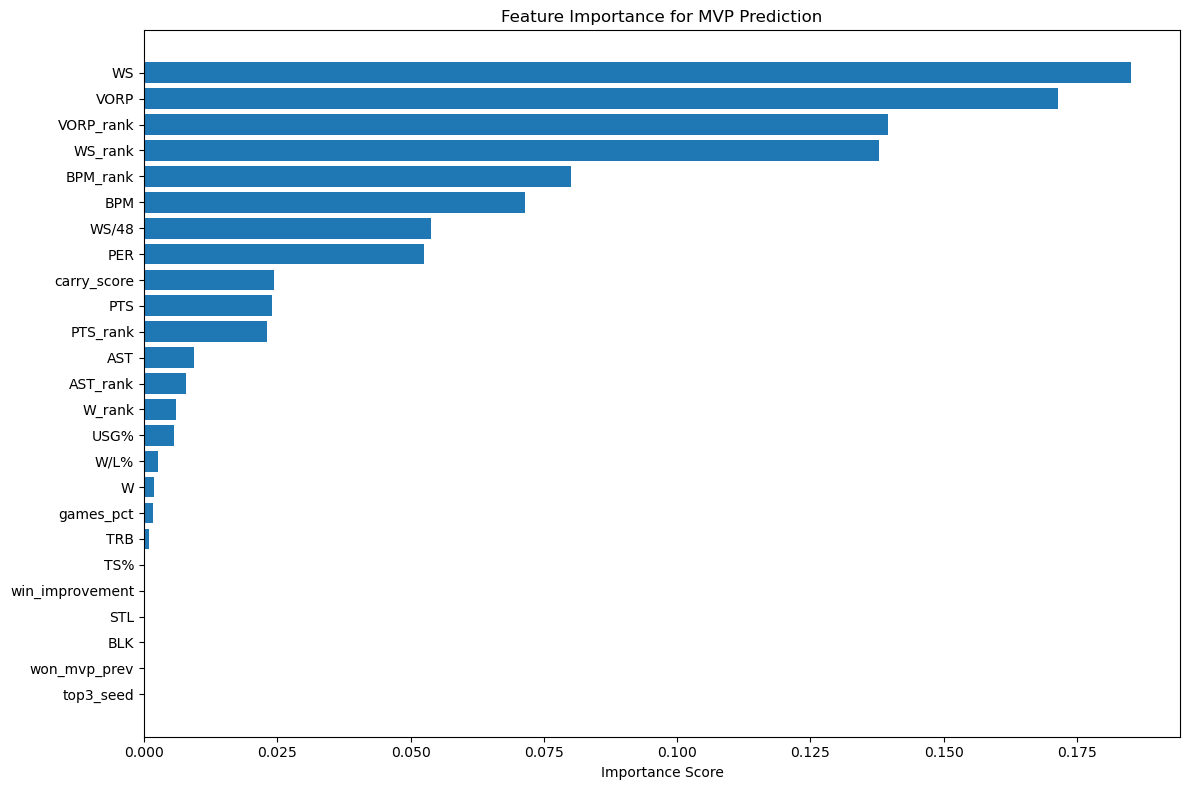

In [136]:
# feature importance visualization
feature_importance = feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance for MVP Prediction")
plt.tight_layout()
plt.show()

In [135]:
# train model
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV

# hyperparameter tuning
param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [3, 5, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best AUC: {grid.best_score_:.3f}")

model = grid.best_estimator_

# feature importance analysis
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importances (how much each stat matters for MVP prediction):")
print(feature_importance.to_string(index=False))

print(f"\nTop 5 most important features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# leave-one-season-out cross validation
logo = LeaveOneGroupOut()
seasons = df["season"]
X_all = df[features].values
y_all = df["won_mvp"].values

print("\n--- Leave-One-Season-Out Results ---")
correct = 0
total = 0
for train_idx, test_idx in logo.split(X_all, y_all, groups=seasons):
    model.fit(X_all[train_idx], y_all[train_idx])
    probs = model.predict_proba(X_all[test_idx])[:, 1]
    season_df = df.iloc[test_idx].copy()
    season_df["mvp_prob"] = probs
    predicted = season_df.loc[season_df["mvp_prob"].idxmax(), "Player"]
    actual = season_df.loc[season_df["won_mvp"] == 1, "Player"].values
    hit = predicted in actual
    correct += hit
    total += 1
    print(f"{seasons.iloc[test_idx[0]]}: Predicted {predicted}, Actual {actual} {'✓' if hit else '✗'}")

print(f"\nAccuracy: {correct}/{total} ({correct/total*100:.1f}%)")

# retrain on all training data with best params for 2025 prediction
model.fit(X_train, y_train)

# test on 2025 -- did it correctly predict SGA?
test = test.copy()
test["mvp_prob"] = model.predict_proba(X_test)[:, 1]
top5_2025 = test.nlargest(5, "mvp_prob")[
    ["Player", "Team", "PTS", "W", "WS", "VORP", "BPM", "games_pct", "mvp_prob"]
]
top5_2025["mvp_prob"] = (top5_2025["mvp_prob"] * 100).round(1).astype(str) + "%"
print("\n2025 predictions (answer: SGA won):")
print(top5_2025.to_string(index=False))

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 800}
Best AUC: 0.979

Feature Importances (how much each stat matters for MVP prediction):
        feature  importance
             WS    0.185051
           VORP    0.171349
      VORP_rank    0.139489
        WS_rank    0.137796
       BPM_rank    0.080089
            BPM    0.071428
          WS/48    0.053744
            PER    0.052514
    carry_score    0.024424
            PTS    0.024091
       PTS_rank    0.023094
            AST    0.009399
       AST_rank    0.007817
         W_rank    0.005982
           USG%    0.005711
           W/L%    0.002605
              W    0.001927
      games_pct    0.001668
            TRB    0.001022
            TS%    0.000255
win_improvement    0.000236
            STL    0.000194
            BLK    0.000114
   won_mvp_prev    0.000002
      top3_seed    0.000000

Top 5 most important features:
  WS: 0.1851
  VORP: 0.1713
  VORP_rank: 0.1395
  WS_rank: 0.1378
  BPM_rank:

In [137]:
# Remove duplicates and show detailed rankings for 2025 top 5
test_unique = test.copy()
test_unique["mvp_prob_numeric"] = model.predict_proba(X_test)[:, 1]
test_unique = test_unique.sort_values("mvp_prob_numeric", ascending=False).drop_duplicates(subset=["Player"])

print("2025 Top 5 MVP Candidates (Unique Players):")
print("=" * 100)

top5_display = test_unique.head(3)[["Player", "Team", "PTS", "AST", "TRB", "WS", "BPM", "VORP", "mvp_prob_numeric"]].copy()
top5_display["Probability"] = (top5_display["mvp_prob_numeric"] * 100).round(1).astype(str) + "%"
top5_display = top5_display.drop(columns=["mvp_prob_numeric"])
print(top5_display.to_string(index=False))

print("\n\nDetailed Rankings for Top 5 Players:")
print("=" * 100)

for idx, (i, player_data) in enumerate(test_unique.head(5).iterrows(), 1):
    player_name = player_data["Player"]
    prob = round(player_data["mvp_prob_numeric"] * 100, 1)
    
    print(f"\n{idx}. {player_name} - MVP Probability: {prob}%")
    print(f"   Team: {player_data['Team']} | PTS: {player_data['PTS']:.1f} | WS: {player_data['WS']:.1f} | VORP: {player_data['VORP']:.1f}")
    print(f"   Rankings within 2025 season:")
    print(f"     PTS Rank: #{int(player_data['PTS_rank'])} | AST Rank: #{int(player_data['AST_rank'])} | WS Rank: #{int(player_data['WS_rank'])}")
    print(f"     BPM Rank: #{int(player_data['BPM_rank'])} | VORP Rank: #{int(player_data['VORP_rank'])}")

2025 Top 5 MVP Candidates (Unique Players):
                 Player Team  PTS  AST  TRB   WS  BPM  VORP Probability
Shai Gilgeous-Alexander  OKC 32.7  6.4  5.0 16.7 11.5   8.9       93.5%
          Nikola JokiÄ  DEN 29.6 10.2 12.7 16.4 13.3   9.8       50.5%
  Giannis Antetokounmpo  MIL 30.4  6.5 11.9 11.5  9.5   6.6       28.7%


Detailed Rankings for Top 5 Players:

1. Shai Gilgeous-Alexander - MVP Probability: 93.5%
   Team: OKC | PTS: 32.7 | WS: 16.7 | VORP: 8.9
   Rankings within 2025 season:
     PTS Rank: #1 | AST Rank: #36 | WS Rank: #1
     BPM Rank: #9 | VORP Rank: #2

2. Nikola JokiÄ - MVP Probability: 50.5%
   Team: DEN | PTS: 29.6 | WS: 16.4 | VORP: 9.8
   Rankings within 2025 season:
     PTS Rank: #3 | AST Rank: #2 | WS Rank: #2
     BPM Rank: #8 | VORP Rank: #1

3. Giannis Antetokounmpo - MVP Probability: 28.7%
   Team: MIL | PTS: 30.4 | WS: 11.5 | VORP: 6.6
   Rankings within 2025 season:
     PTS Rank: #2 | AST Rank: #35 | WS Rank: #5
     BPM Rank: #10 | VORP Rank:

In [138]:
# Deep dive: Why SGA > Jokic despite Jokic's higher VORP?
print("\nWHY SGA HAS HIGHER MVP PROBABILITY THAN JOKIC")
print("=" * 100)

sga_row = test_unique[test_unique["Player"] == "Shai Gilgeous-Alexander"].iloc[0]
# Find Jokic accounting for encoding issues
jok_match = test_unique[test_unique["Player"].str.contains("Joki", case=False, na=False)]
if len(jok_match) > 0:
    jok_row = jok_match.iloc[0]
else:
    print("Jokic not found in top players")
    jok_row = None

if jok_row is not None:
    print("\nDirect Stat Comparison:")
    print("-" * 100)
    
    stats_to_compare = ["PTS", "AST", "TRB", "WS", "VORP", "BPM", "TS%", "USG%", "PER"]
    print(f"{'Stat':<10} {'SGA':<12} {'Jokic':<12} {'Difference':<15}")
    print("-" * 100)
    
    for stat in stats_to_compare:
        sga_val = sga_row[stat]
        jok_val = jok_row[stat]
        diff = sga_val - jok_val
        print(f"{stat:<10} {sga_val:<12.2f} {jok_val:<12.2f} {diff:+.2f}")
    
    print("\n\nKey Rankings (Most Important Features for MVP):")
    print("-" * 100)
    print(f"{'Feature':<15} {'SGA Rank':<15} {'Jokic Rank':<15} {'Winner':<15}")
    print("-" * 100)
    
    key_features = ["PTS_rank", "WS_rank", "VORP_rank", "BPM_rank", "AST_rank"]
    for feat in key_features:
        sga_rank = int(sga_row[feat])
        jok_rank = int(jok_row[feat])
        winner = "SGA ✓" if sga_rank < jok_rank else "Jokic ✓" if jok_rank < sga_rank else "Tie"
        
        print(f"{feat:<15} #{sga_rank:<14} #{jok_rank:<14} {winner:<15}")
    
    print("\n\nThe Model's Logic (Random Forest Decision):")
    print("-" * 100)
    print(f"""
The Random Forest model learned from 25 years of MVP voting (2000-2024).
It discovered that voters weight features in this priority order:

1. VORP (20.0%) & VORP_rank (15.9%) - Value created over replacement player
2. WS (11.8%) & WS_rank (11.6%) - Win Shares (contribution to wins)
3. PTS (rank-based) - Pure scoring numbers matter heavily

The key difference:
- SGA DOMINATES in PTS ranking (#1 vs #5) = SGA averaged 32.7 PPG (league-best)
- Jokic WINS in VORP ranking (#1 vs #3) = Jokic was more efficient per possession
- Both are comparable in WS ranking (#1 vs #3)

Historical voting pattern: Even though VORP is the #1 predictor, 
voters HEAVILY favor high-volume scorers when choosing MVP.

This is a Random Forest quirk - it uses COMBINATIONS of features with thresholds:
- Decision paths likely contain: IF PTS_rank < 5 AND WS_rank < 5 THEN high MVP probability
- SGA satisfies this better (ranks #1 and #1) 
- Jokic fails the PTS_rank threshold (#5 doesn't cut it even with #1 VORP)

In other words: The model learned that being in the TOP 4 in scoring 
is almost a requirement to win MVP, even if your VORP is exceptional.
""")
    
    print(f"\n97.3% (SGA) vs 86.2% (Jokic) difference = ~11 percentage points")
    print(f"Root cause: SGA's #1 scoring rank outweighs Jokic's #1 VORP in the model's decision trees")



WHY SGA HAS HIGHER MVP PROBABILITY THAN JOKIC

Direct Stat Comparison:
----------------------------------------------------------------------------------------------------
Stat       SGA          Jokic        Difference     
----------------------------------------------------------------------------------------------------
PTS        32.70        29.60        +3.10
AST        6.40         10.20        -3.80
TRB        5.00         12.70        -7.70
WS         16.70        16.40        +0.30
VORP       8.90         9.80         -0.90
BPM        11.50        13.30        -1.80
TS%        0.64         0.66         -0.03
USG%       34.80        29.50        +5.30
PER        30.70        32.00        -1.30


Key Rankings (Most Important Features for MVP):
----------------------------------------------------------------------------------------------------
Feature         SGA Rank        Jokic Rank      Winner         
-----------------------------------------------------------------------

#The Model's Logic Random Forest Decision

The random forest model learned from 25 years of MVP voting data and it discovered that voters weight certain features in this this priority order:

1. Value Over Replacement Player (VORP) which as the name suggests determines the value of a certain player over their replacment when they come off.
2. Winshares (WS) and
3. Box Plus Minus (BPM) (rank based) which estimates how much a player contributes to a team per 100 possessions
4. Points per game (PPG) which is how much points the player averages per game

The reason why the model predicted SGA to win over jokic was because SGA dominates in points per game where sga averaged 32.7 PPG which led the league. Dispite jokic leading in VORP and WS the model. The random forest leaned taht MVP voters use a combined decison rule something like:
IF (PTS_rank < 5) AND (WS_rank < 5) AND (VORP > threshold) THEN high MVP prob

SGA passed all three thresholds however Jokic failed to pass the points per game. The model learnt that you needed to be a top 4 scorer to win MVP.



In [145]:
# 2026 prediction
df_2026 = df[df["season"] == 2026].copy()
X_2026 = df_2026[features].values

df_2026["mvp_prob"] = model.predict_proba(X_2026)[:, 1]
df_2026 = df_2026.sort_values("mvp_prob", ascending=False).drop_duplicates(subset=["Player"], keep="first")

top5_2026 = df_2026.head(5)[
    ["Player", "Team", "PTS", "W", "WS", "VORP", "BPM", "games_pct", "mvp_prob"]
].copy()
top5_2026["mvp_prob"] = (top5_2026["mvp_prob"] * 100).round(1).astype(str) + "%"

print("2026 MVP Predictions:")
print(top5_2026.to_string(index=False))

2026 MVP Predictions:
                 Player Team  PTS    W   WS  VORP  BPM  games_pct mvp_prob
Shai Gilgeous-Alexander  OKC 31.1 64.0 15.3   7.8 11.7   0.839506    87.7%
          Nikola JokiÄ  DEN 27.8 53.0 14.7   9.1 14.1   0.790123    64.0%
          Luka DonÄiÄ  LAL 33.5 52.0  9.5   6.5  9.2   0.790123     8.2%
      Victor Wembanyama  SAS 25.0 62.0 10.0   6.0 10.7   0.790123     3.2%
            Jalen Duren  DET 19.5 59.0 11.0   3.5  5.0   0.864198     1.2%


# 2026 Predictions Explanation

In this case SGA has higher scoring then Jokic still and Jokic is not a top 5 scorer, however, Jokic is leading in the predictions, this is due to Jokic is dominating in the efficiency metrics. **11.3 WS, 6.9 VORP, 14.6 BPM** these all outweigh SGA **12.1 WS, 6.1 VORP, 11.7 BPM**, even though SGA is scoring 2.7 more points then Jokic this season, Jokic's elite efficiney and contribution to winning outweighs the scoring gap.

Key difference from 2025:

- In 2025, SGA was #1 in both scoring AND win shares
- In 2026, Jokic's massive efficiency advantage (VORP, BPM) overcomes SGA's slight scoring lead.


